<a href="https://colab.research.google.com/github/sejalkashyap60/GenAI/blob/main/Prac2_gen_ai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install required libraries
!pip install gensim scikit-learn matplotlib plotly pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 66.4 MB/s eta 0:00:00


In [ ]:
from gensim.models import Word2Vec

# Training sentences
sentences = [
    ['the', 'king', 'rules', 'the', 'kingdom'],
    ['the', 'queen', 'rules', 'the', 'kingdom'],
    ['the', 'prince', 'rules', 'the', 'kingdom'],
    ['the', 'apple', 'is', 'a', 'tasty', 'fruit'],
    ['a', 'banana', 'is', 'a', 'tasty', 'fruit'],
    ['an', 'orange', 'is', 'a', 'tasty', 'fruit']
]

print("---- Training Models ------")

# CBOW Model
model_cbow = Word2Vec(
    sentences,
    vector_size=10,
    window=2,
    min_count=1,
    sg=0,
    epochs=100
)

print("CBOW model trained successfully.")

# Skip-Gram Model
model_skipgram = Word2Vec(
    sentences,
    vector_size=10,
    window=2,
    min_count=1,
    sg=1,
    epochs=100
)

print("Skip-Gram model trained successfully.\n")


# Function to test similarities
def test_similarities(model, model_name):

    print(f"--- Semantic Similarities using {model_name} ---")

    sim_royal = model.wv.similarity('queen', 'king')
    print(f"Similarity ('queen', 'king'): {sim_royal:.4f}")

    sim_fruit = model.wv.similarity('apple', 'is')
    print(f"Similarity ('apple', 'is'): {sim_fruit:.4f}")

    sim_unrelated = model.wv.similarity('queen', 'apple')
    print(
        f"Similarity of unrelated words ('queen', 'apple'): "
        f"{sim_unrelated:.4f}"
    )

    print("-" * 40)


# Test CBOW
test_similarities(model_cbow, "CBOW Model")

# Test Skip-Gram
test_similarities(model_skipgram, "Skip-Gram Model")

---- Training Models ------
CBOW model trained successfully.
Skip-Gram model trained successfully.

--- Semantic Similarities using CBOW Model ---
Similarity ('queen', 'king'): 0.4364
Similarity ('apple', 'is'): 0.0378
Similarity of unrelated words ('queen', 'apple'): -0.0937
----------------------------------------
--- Semantic Similarities using Skip-Gram Model ---
Similarity ('queen', 'king'): 0.4356
Similarity ('apple', 'is'): 0.0407
Similarity of unrelated words ('queen', 'apple'): -0.0939
----------------------------------------


In [ ]:
import gensim.downloader as api

print("Loading pre-trained Word2Vec model...")

# Download and load the pre-trained Google News Word2Vec model
model = api.load("word2vec-google-news-300")

print("Pre-trained model loaded successfully.")

# Find words similar to Google
print("\nWords most similar to 'google':")

similar_words = model.most_similar("google")

for word, similarity in similar_words:
    print(f"{word}: {similarity:.4f}")

Loading pre-trained Word2Vec model...
[==================================================] 100.0% 1662.8/1662.8MB downloaded
Pre-trained model loaded successfully.

Words most similar to 'google':
google.com: 0.6711
google_yahoo: 0.6488
wikipedia: 0.6436
www.google.com: 0.6259
googled: 0.6166
googling: 0.6086
slashdot: 0.5965
lifehacker: 0.5949
gizmodo: 0.5884
inurl: 0.5883


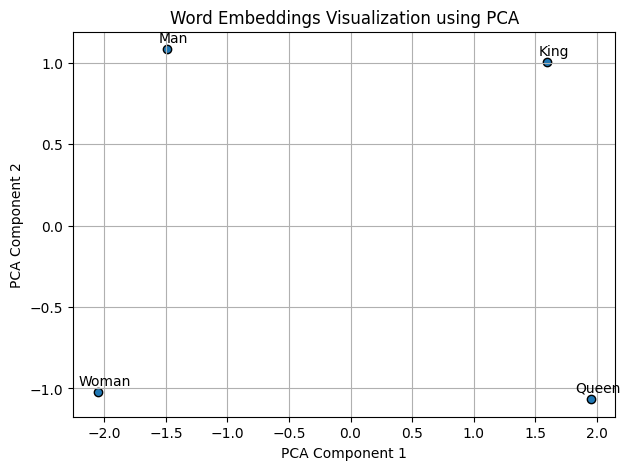

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Select words for visualization
words_to_visualize = [
    'King',
    'Queen',
    'Man',
    'Woman'
]

# Filter words available in the model vocabulary
filtered_words = [
    word for word in words_to_visualize
    if word in model.key_to_index
]

# Get word vectors
vectors = [
    model[word]
    for word in filtered_words
]

# Reduce 300-dimensional vectors to 2 dimensions
pca = PCA(n_components=2)
vectors_2d = pca.fit_transform(vectors)

# Create scatter plot
plt.figure(figsize=(7, 5))

plt.scatter(
    vectors_2d[:, 0],
    vectors_2d[:, 1],
    edgecolors='k'
)

# Add labels
for i, word in enumerate(filtered_words):
    plt.annotate(
        word,
        (vectors_2d[i, 0], vectors_2d[i, 1]),
        textcoords="offset points",
        xytext=(5, 5),
        ha='center'
    )

plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Word Embeddings Visualization using PCA')
plt.grid(True)
plt.show()